In [1]:
# Imports

import numpy as np
import pandas as pd
from scipy.linalg import lstsq
from sympy import *
import matplotlib.pyplot as plt
import time as tm
start_time = tm.time()
init_printing(use_latex=true)
filename = "TestDataLots.xlsx"

## LFO

In [45]:
# Establish symbols
n, T, k, i, t, lda, eps = symbols('n T k i t \lambda \epsilon')       
# n wells & T timepoints
# k = highest degree of w polynomial

In [46]:
# Choose highest degree of polynomial
k = 1

In [47]:
# Establish number of wells
n = pd.read_excel(filename, sheet_name='n').iloc[0,0]
n

5

In [48]:
# Establish number of timepoints
T = pd.read_excel(filename, sheet_name='T').iloc[0,0]
T

41

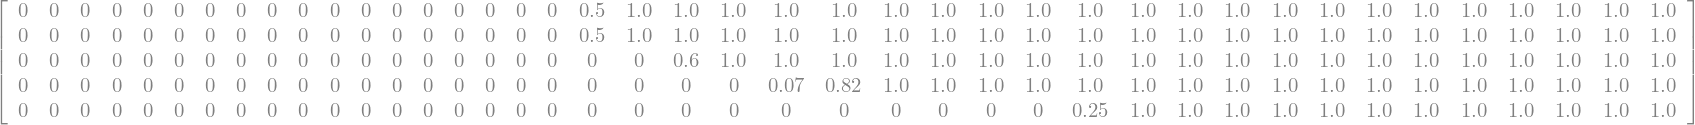

In [49]:
# Establish binary matrix for wells being on or off
z = MatrixSymbol('z', n, T)      # Row 0 = well 0   , Column 3 = Timepoint 3
#pprint(z.as_explicit())
zReal = Matrix(pd.read_excel(filename, sheet_name="OnOff").to_numpy().T)
zReal

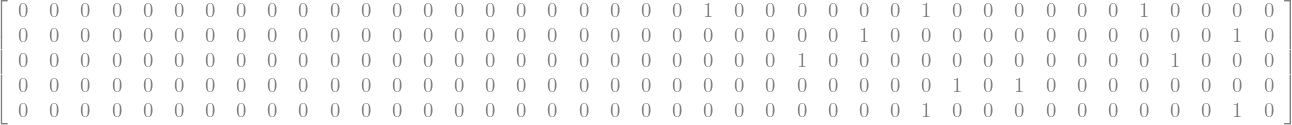

In [50]:
# Establish binary matrix for wells being measured or not
d = MatrixSymbol('d', n, T)      # Row 0 = well 0   , Column 3 = Timepoint 3
#pprint(d.as_explicit())
dReal = Matrix(pd.read_excel(filename, sheet_name="Measured").to_numpy().T)
dTotal = sum(dReal)
dReal

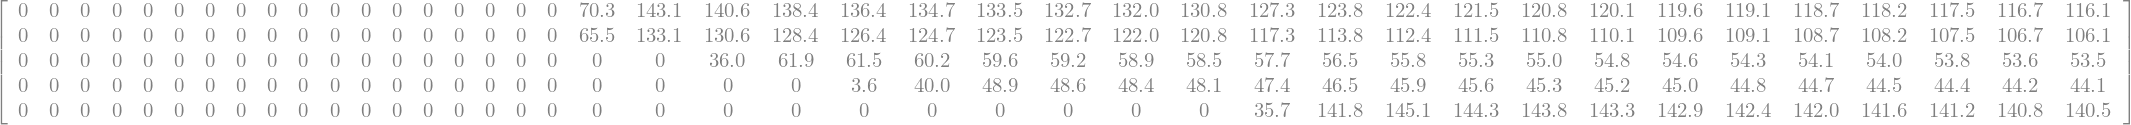

In [51]:
# Establish matrix of actual mass flows
m = MatrixSymbol('m', n, T)  
#pprint(m.as_explicit())
mReal = Matrix(pd.read_excel(filename, sheet_name="MassFlows").to_numpy().T)
mReal

In [52]:
# Establish matrix / vector of total mass flow
M = MatrixSymbol('M', 1, T)
#pprint(M.as_explicit())
MReal = Matrix(pd.read_excel(filename, sheet_name="TotalMassFlow").to_numpy().T)
MReal

In [53]:
# Set w as an expression based on t
wMat = MatrixSymbol('w', n, k+1)
pprint(wMat.as_explicit())

⎡w₀₀  w₀₁⎤
⎢        ⎥
⎢w₁₀  w₁₁⎥
⎢        ⎥
⎢w₂₀  w₂₁⎥
⎢        ⎥
⎢w₃₀  w₃₁⎥
⎢        ⎥
⎣w₄₀  w₄₁⎦


In [54]:
# Instantaneous value of wi is wMati * [1, t, t^2, t^3 etc]
tList = []
for power in range(k+1):
    tList.append(t**power)
ts = Matrix(tList)
wInstant = Matrix([wMat[i,:].as_explicit().dot(ts) for i in range(n)])
wInstant[0,0]

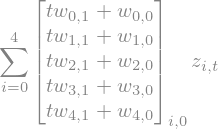

In [55]:
Sum(z[i, t]*wInstant[i, 0], (i, 0, n-1))

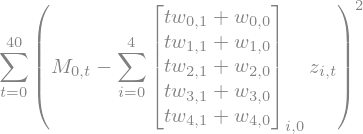

In [56]:
S1 = Sum((M[0,t] - Sum(z[i, t]*wInstant[i,0], (i, 0, n-1)))**2 , (t, 0, T-1))
S1

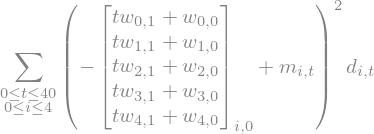

In [57]:
S2 = Sum(Sum(d[i,t]*((m[i,t]-wInstant[i,0]))**2 , (t, 0, T-1)), (i, 0, n-1))
S2

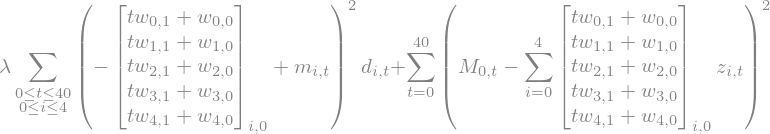

In [58]:
I = S1 + lda*S2
I

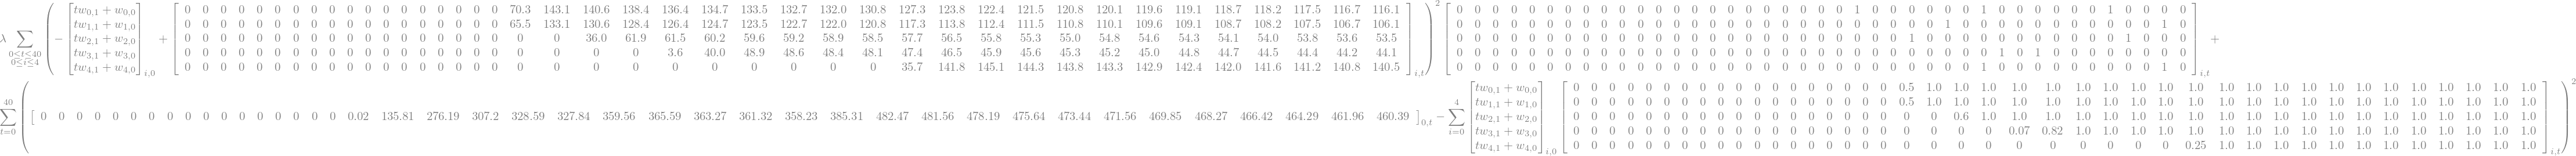

In [59]:
Inac = I.subs({M: MReal, z: zReal, d: dReal, m: mReal})
Inac

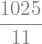

In [60]:
optLda = T*n**2/dTotal
Inaccuracy = Inac.subs(lda, optLda)
optLda

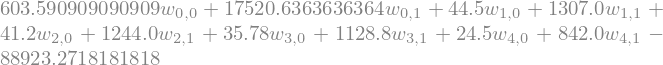

In [61]:
Inaccuracy.diff(wMat[0,0]).doit()

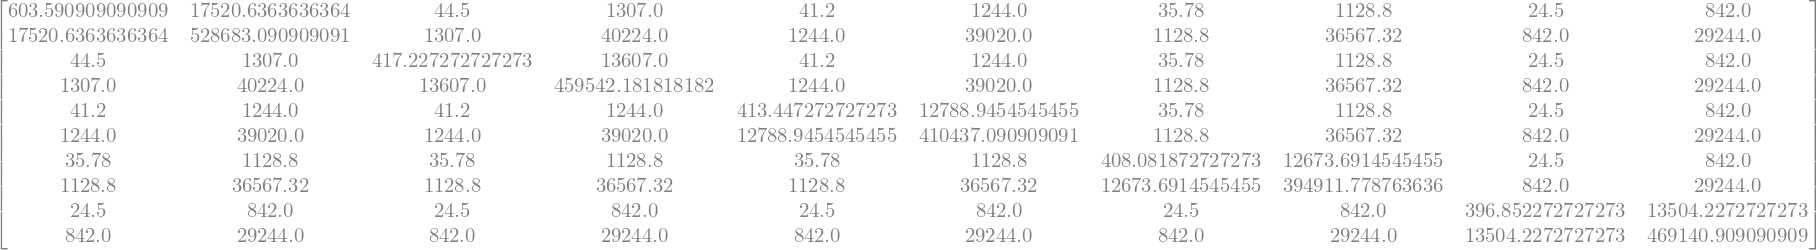

In [62]:
DiffA = np.zeros([(k+1)*n,(k+1)*n])
Diffb = np.zeros((k+1)*n)
# Fill in matrix with values for Aw=b  
for i in range(n):
    for j in range(k+1):
        # v = vertical index
        v = i*(k+1)+j
        dwij = Poly(Inaccuracy.diff(wMat[i,j]).doit())
        Diffb[v] = -1*dwij.coeffs()[-1]
        for i2 in range(n):
            for j2 in range(k+1):
                # h = horizontal index
                h = i2*(k+1)+j2
                #print(v, h)
                DiffA[v,h] = dwij.coeff_monomial(wMat[i2, j2])
                
    
# Then solve for w
DiffMatrixA = Matrix(DiffA)
DiffMatrixb = Matrix(Diffb)
DiffMatrixA

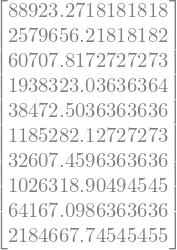

In [63]:
DiffMatrixb

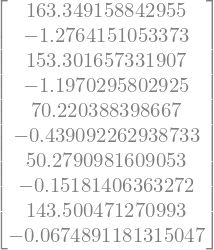

In [64]:
results = DiffMatrixA.inv()*DiffMatrixb
results

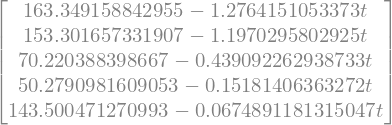

In [65]:
LFO = results.reshape(n, k+1)*ts
LFO

## LLSO

In [66]:
# Establish number of wells
n = pd.read_excel(filename, sheet_name='n').iloc[0,0]
n

5

In [67]:
# Establish number of timepoints
T = pd.read_excel(filename, sheet_name='T').iloc[0,0]
T

41

In [68]:
zReal = pd.read_excel(filename, sheet_name="OnOff").to_numpy().T
zReal

array([[0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
        0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.5 , 1.  , 1.  , 1.  ,
        1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  ,
        1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
        0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.5 , 1.  , 1.  , 1.  ,
        1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  ,
        1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
        0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.6 , 1.  ,
        1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  ,
        1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
        0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
        0.07, 0

In [69]:
dReal = pd.read_excel(filename, sheet_name="Measured").to_numpy().T
dTotal = np.sum(dReal)
dReal

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0]])

In [70]:
# Establish vector of actual mass flows
mReal = pd.read_excel(filename, sheet_name="MassFlows").to_numpy().T
mReal

array([[  0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,
          0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,
         70.3, 143.1, 140.6, 138.4, 136.4, 134.7, 133.5, 132.7, 132. ,
        130.8, 127.3, 123.8, 122.4, 121.5, 120.8, 120.1, 119.6, 119.1,
        118.7, 118.2, 117.5, 116.7, 116.1],
       [  0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,
          0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,
         65.5, 133.1, 130.6, 128.4, 126.4, 124.7, 123.5, 122.7, 122. ,
        120.8, 117.3, 113.8, 112.4, 111.5, 110.8, 110.1, 109.6, 109.1,
        108.7, 108.2, 107.5, 106.7, 106.1],
       [  0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,
          0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,
          0. ,   0. ,  36. ,  61.9,  61.5,  60.2,  59.6,  59.2,  58.9,
         58.5,  57.7,  56.5,  55.8,  55.3,  55. ,  54.8,  54.6,  54.3,
         54.1,  54. ,  53.8,  53.6,  53.5],
       [  0. ,  

In [71]:
# Establish matrix / vector of total mass flow
MReal = pd.read_excel(filename, sheet_name="TotalMassFlow").to_numpy().T
MReal

array([[0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 2.0000e-02, 1.3581e+02, 2.7619e+02,
        3.0720e+02, 3.2859e+02, 3.2784e+02, 3.5956e+02, 3.6559e+02,
        3.6327e+02, 3.6132e+02, 3.5823e+02, 3.8531e+02, 4.8247e+02,
        4.8156e+02, 4.7819e+02, 4.7564e+02, 4.7344e+02, 4.7156e+02,
        4.6985e+02, 4.6827e+02, 4.6642e+02, 4.6429e+02, 4.6196e+02,
        4.6039e+02]])

In [72]:
Lambda1 = T*n**2/dTotal
Lambda1

In [73]:
# Compile the y vector (col. vec.)
y = np.zeros([T*(n+1)+n*(T-1)+n*(T-2), 1])
for j in range(T):
    # fill in m values
    for i in range(n):
        y[T*i+j, 0] = mReal[i,j]  * np.sqrt(Lambda1)# * dReal[i,j]  # Seems to have no effect
    # fill in M values
    y[T*n+j, 0] = MReal[0,j]
y.shape

In [74]:
# Compile the A1 matrix
A1 = np.zeros([T*(n+1)+n*(T-1)+n*(T-2), n*T])
for i in range(n):
    for j in range(T):
        # fill in d values
        A1[T*i+j, T*i+j] = np.sqrt(Lambda1) * dReal[i,j]
        # fill in z values
        A1[T*n+j, T*i+j] = zReal[i,j]
        #print([n*T+j, T*i+j])
    
A1.shape 

In [75]:
# Compile the A2 matrix
# Use t's uniformly spaced 1 apart
ts = np.array(list(range(T)))+1
A2 = np.zeros([n*T, n*(k+1)])
for block in range(n):
    for r in range(T):
        for c in range(k+1):
            A2[block*T + r, block*(k+1) + c] = ts[r]**c

A2.shape

In [76]:
# Calculate final A matrix
A = np.matmul(A1,A2)
A.shape

In [77]:
res, _, _, _ = lstsq(A, y)
res = res.reshape(n, k+1)
res

array([[ 1.64625574e+02, -1.27641511e+00],
       [ 1.54498687e+02, -1.19702958e+00],
       [ 7.06594807e+01, -4.39092263e-01],
       [ 5.04309122e+01, -1.51814064e-01],
       [ 1.43567960e+02, -6.74891181e-02]])

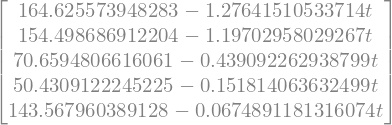

In [78]:
# Coerce results into desired format for printing
t = symbols('t')
LLSO = Matrix(np.zeros(n))
for i in range(n):
    for deg in range(k+1):
        #print(res[i,deg]*t**deg)
        LLSO[i] = LLSO[i] + res[i,deg]*t**deg

LLSO

Bayesian model based on normal distribution of provided data. Bishop book

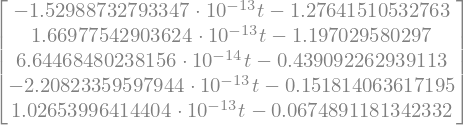

In [79]:
DifferenceBetween = LFO - LLSO
DifferenceBetween

In [80]:
# Calculate average out of sample squared error (MSE). Then sqrt
SE = 0
for i in range(n):
    for t2 in range(T):
        RSS = (zReal[i,t2]*DifferenceBetween[i].subs(t, t2))**2
        SE = SE + RSS

MSE = SE / n / T
RMSE = sqrt(MSE)
RMSE

In [ ]:
k=2 gives 0.696796766388796